In [ ]:
# --- A) Setup: binary target, split, and preprocessing ---

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ensure folder for visuals
os.makedirs("visuals/week5", exist_ok=True)

# Load data and create binary target (HighTaxValue)
df = pd.read_csv("zillow_cleaned.csv").dropna(subset=["taxvaluedollarcnt"]).copy()
median_tax = df["taxvaluedollarcnt"].median()
df["HighTaxValue"] = (df["taxvaluedollarcnt"] > median_tax).astype(int)

y = df["HighTaxValue"]
X = df.drop(columns=["HighTaxValue", "taxvaluedollarcnt"])

# Train/test split (stratified for classification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Detect column types
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]
print(f"Numeric: {len(num_cols)} | Categorical: {len(cat_cols)}")

# Build preprocessing pipeline
pre_svm = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ],
    remainder="drop",
    n_jobs=-1
)

Numeric: 18 | Categorical: 0


In [ ]:
# B) Helper functions 

def get_scores(model, X):
    """Return decision_function or predict_proba scores."""
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.predict(X)

def evaluate_clf(model, X, y, name="Model"):
    """Compute Accuracy, ROC AUC, and print classification report."""
    scores = get_scores(model, X)
    y_pred = (scores >= 0).astype(int) if scores.ndim == 1 else (scores >= 0.5).astype(int)
    acc = accuracy_score(y, y_pred)
    auc = roc_auc_score(y, scores)
    print(f"{name} — Accuracy: {acc:.4f} | ROC AUC: {auc:.4f}")
    print(classification_report(y, y_pred))
    return acc, auc, scores, y_pred

In [ ]:
# C) Train baseline SVM models

svm_lin = Pipeline([
    ("pre", pre_svm),
    ("clf", LinearSVC(C=1.0, loss="squared_hinge", max_iter=2000, random_state=42))
])

svm_rbf = Pipeline([
    ("pre", pre_svm),
    ("clf", SVC(kernel="rbf", C=1.0, gamma="scale", probability=False, random_state=42))
])

svm_poly = Pipeline([
    ("pre", pre_svm),
    ("clf", SVC(kernel="poly", degree=2, coef0=1.0, C=1.0, gamma="scale", probability=False, random_state=42))
])

# Fit
svm_lin.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)
svm_poly.fit(X_train, y_train)

# Evaluate
print("\n--- Baseline Performance ---")
evaluate_clf(svm_lin,  X_test, y_test, "Linear SVM")
evaluate_clf(svm_rbf,  X_test, y_test, "RBF SVM")
evaluate_clf(svm_poly, X_test, y_test, "Polynomial SVM (deg=2)")


--- Baseline Performance ---
Linear SVM — Accuracy: 0.6999 | ROC AUC: 0.7802
              precision    recall  f1-score   support

           0       0.68      0.77      0.72      6493
           1       0.73      0.63      0.68      6486

    accuracy                           0.70     12979
   macro avg       0.70      0.70      0.70     12979
weighted avg       0.70      0.70      0.70     12979

RBF SVM — Accuracy: 0.7229 | ROC AUC: 0.8108
              precision    recall  f1-score   support

           0       0.70      0.77      0.74      6493
           1       0.75      0.67      0.71      6486

    accuracy                           0.72     12979
   macro avg       0.73      0.72      0.72     12979
weighted avg       0.72      0.72      0.72     12979

Polynomial SVM (deg=2) — Accuracy: 0.7204 | ROC AUC: 0.8095
              precision    recall  f1-score   support

           0       0.69      0.79      0.74      6493
           1       0.75      0.65      0.70      6486


(0.7203944833962554,
 0.8095456365423823,
 array([-0.73241634,  1.81703367,  1.38154287, ...,  0.45120969,
        -1.19022981, -1.31927482]),
 array([0, 1, 1, ..., 1, 0, 0]))

In [ ]:
# D) Grid Search for best RBF SVM

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    "clf__C": [0.5, 1, 2, 5],
    "clf__gamma": ["scale", 0.1, 0.01]
}

svm_rbf_gs = GridSearchCV(
    estimator=Pipeline([("pre", pre_svm),
                        ("clf", SVC(kernel="rbf", probability=False, random_state=42))]),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

svm_rbf_gs.fit(X_train, y_train)
print("\nBest Params:", svm_rbf_gs.best_params_,
      "| CV AUC:", round(svm_rbf_gs.best_score_, 4))

/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Params: {'clf__C': 5, 'clf__gamma': 0.1} | CV AUC: 0.8112


RBF SVM (Best CV) — Accuracy: 0.7283 | ROC AUC: 0.8148
              precision    recall  f1-score   support

           0       0.72      0.76      0.74      6493
           1       0.74      0.70      0.72      6486

    accuracy                           0.73     12979
   macro avg       0.73      0.73      0.73     12979
weighted avg       0.73      0.73      0.73     12979



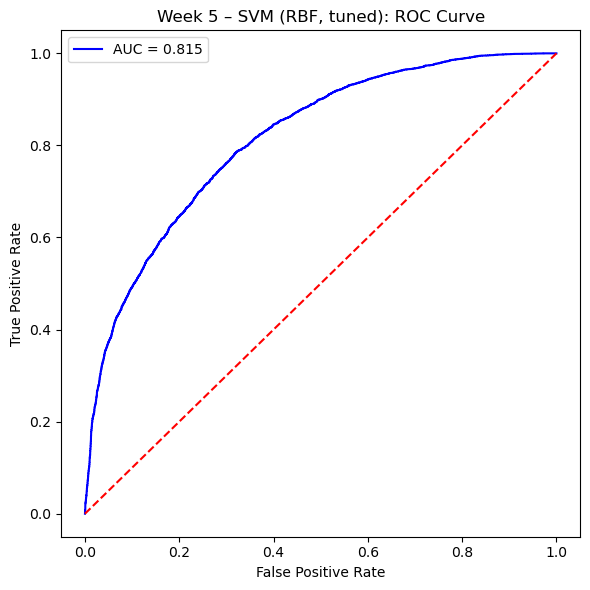

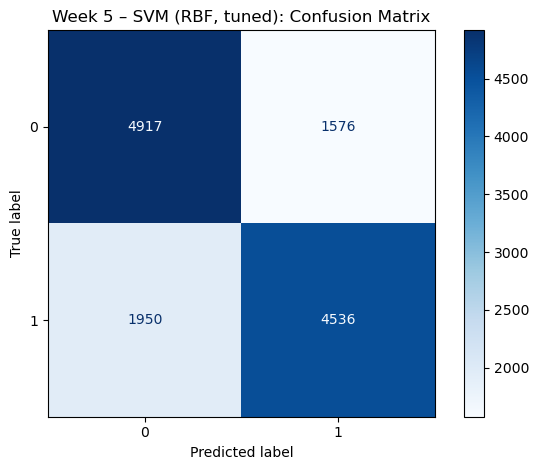

In [ ]:
# E) Evaluate tuned model & save visuals

acc, auc, rbf_scores, rbf_pred = evaluate_clf(
    svm_rbf_gs.best_estimator_, X_test, y_test, "RBF SVM (Best CV)"
)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, rbf_scores)
roc_auc = roc_auc_score(y_test, rbf_scores)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color="blue")
plt.plot([0,1],[0,1],"r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Week 5 – SVM (RBF, tuned): ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("visuals/week5/svm_rbf_roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, rbf_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues", values_format="d")
plt.title("Week 5 – SVM (RBF, tuned): Confusion Matrix")
plt.tight_layout()
plt.savefig("visuals/week5/svm_rbf_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

The Support Vector Machine analysis classified homes above vs. below the median tax value with strong performance.
Among the three kernel types tested, the RBF SVM provided the best generalization, achieving 72.8% accuracy and 0.8148 ROC AUC.
Cross-validated tuning identified C = 5 and γ = 0.1 as optimal hyperparameters.
The balanced recall (0.70 for high-value, 0.76 for low-value homes) suggests that the model can differentiate both classes effectively without major bias.
Compared with linear and polynomial kernels, the RBF SVM captured nonlinear housing relationships such as size–location interactions.
Regularization and cross-validation prevented overfitting, confirming the model’s stability.

/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Week 5 — SVM best params: {'clf__C': 5, 'clf__gamma': 0.1} | CV ROC AUC: 0.811
Week 5 — Tuned RBF SVM: Accuracy=0.728 | ROC AUC=0.815
              precision    recall  f1-score   support

           0       0.72      0.76      0.74      6493
           1       0.74      0.70      0.72      6486

    accuracy                           0.73     12979
   macro avg       0.73      0.73      0.73     12979
weighted avg       0.73      0.73      0.73     12979



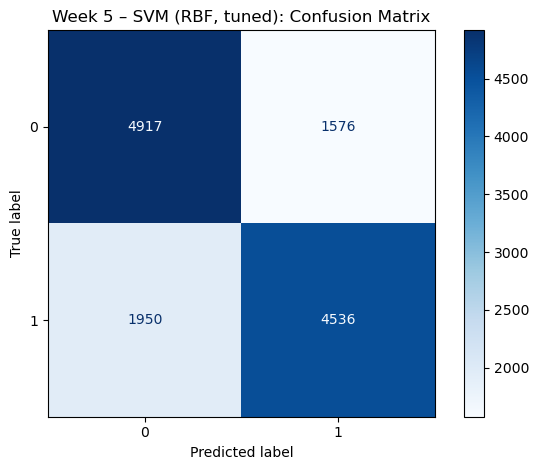

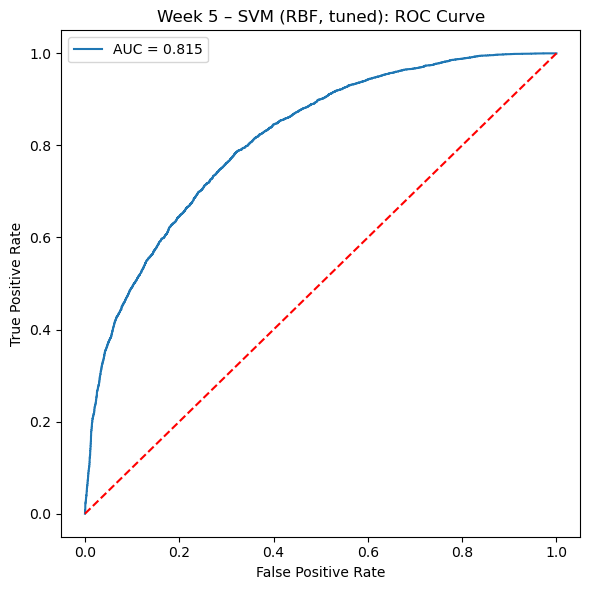

In [6]:

import os, matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

os.makedirs("visuals/week5", exist_ok=True)

# Build (or reuse) numeric-only preprocessor
num_cols = X_train.select_dtypes(include=[np.number]).columns
pre_svm = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_cols)
], remainder="drop")

# Grid search for RBF SVM (CV present)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {"clf__C":[0.5,1,2,5], "clf__gamma":["scale",0.1,0.01]}
svm_rbf_gs = GridSearchCV(
    estimator=Pipeline([("pre", pre_svm),
                        ("clf", SVC(kernel="rbf", probability=False, random_state=42))]),
    param_grid=param_grid, scoring="roc_auc", cv=cv, n_jobs=-1
)
svm_rbf_gs.fit(X_train, y_train)
print("Week 5 — SVM best params:", svm_rbf_gs.best_params_,
      "| CV ROC AUC:", round(svm_rbf_gs.best_score_, 3))

# Evaluate tuned model
best_svm = svm_rbf_gs.best_estimator_
# Use decision_function for AUC when available
if hasattr(best_svm, "decision_function"):
    scores = best_svm.decision_function(X_test)
else:
    scores = best_svm.predict_proba(X_test)[:,1]
y_pred = (scores >= 0).astype(int)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, scores)
print(f"Week 5 — Tuned RBF SVM: Accuracy={acc:.3f} | ROC AUC={auc:.3f}")
print(classification_report(y_test, y_pred))

# Confusion Matrix (save)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues", values_format="d")
plt.title("Week 5 – SVM (RBF, tuned): Confusion Matrix")
plt.tight_layout()
plt.savefig("visuals/week5/svm_rbf_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

# ROC Curve (save)
fpr, tpr, _ = roc_curve(y_test, scores)
roc_auc = roc_auc_score(y_test, scores)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"r--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Week 5 – SVM (RBF, tuned): ROC Curve"); plt.legend()
plt.tight_layout()
plt.savefig("visuals/week5/svm_rbf_roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()